# Bloque I — Análisis descriptivo con pandas

Entrega final con código ejecutable y conclusiones.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
df = pd.read_csv("ventas_mayo_2026.csv")
df.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,836.250
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,956.720
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,357.650
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,301.520
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.090,29,"2,101.550"


## Limpieza de datos

In [3]:
df_limpio = df.copy()

df_limpio = df_limpio.drop_duplicates()

df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])

df_limpio["precio_unitario"] = df_limpio["precio_unitario"].fillna(
    df_limpio["precio_unitario"].median()
)

df_limpio["region"] = df_limpio["region"].fillna("Sin informar")

df_limpio["mes"] = df_limpio["fecha"].dt.month
df_limpio["dia_semana"] = df_limpio["fecha"].dt.day_name()
df_limpio["importe_con_iva"] = df_limpio["importe"] * 1.21
df_limpio["ticket_unitario"] = df_limpio["importe"] / df_limpio["unidades"]

df_limpio.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,mes,dia_semana,importe_con_iva,ticket_unitario
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,836.250,1,Wednesday,"1,011.862",104.531
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,956.720,1,Thursday,"1,157.631",191.344
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,357.650,1,Friday,432.756,51.093
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,301.520,1,Saturday,364.839,33.502
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,118.520,0.090,29,"2,101.550",1,Sunday,"2,542.876",262.694


## Ejercicio integrador

In [4]:
# Ventas por canal
ventas_por_canal = (
    df_limpio.groupby("canal")["importe"]
    .sum()
    .sort_values(ascending=False)
)

ventas_por_canal

canal
Online         261,172.610
Tienda         220,217.410
Distribuidor   136,131.490
Name: importe, dtype: float64

In [5]:
# Ticket medio por región
ticket_medio_region = (
    df_limpio.groupby("region")["importe"]
    .mean()
    .sort_values(ascending=False)
)

ticket_medio_region

region
Sin informar         1,694.522
Valencia             1,276.516
Madrid               1,262.585
Castilla-La Mancha   1,256.707
Andalucía            1,222.422
Cataluña             1,106.741
Name: importe, dtype: float64

In [6]:
# Categoría con más unidades
unidades_por_categoria = (
    df_limpio.groupby("categoria")["unidades"]
    .sum()
    .sort_values(ascending=False)
)

categoria_top_unidades = unidades_por_categoria.index[0]

unidades_por_categoria

categoria
Alimentación    1027
Tecnología      1018
Hogar            866
Servicios        774
Moda             751
Name: unidades, dtype: int64

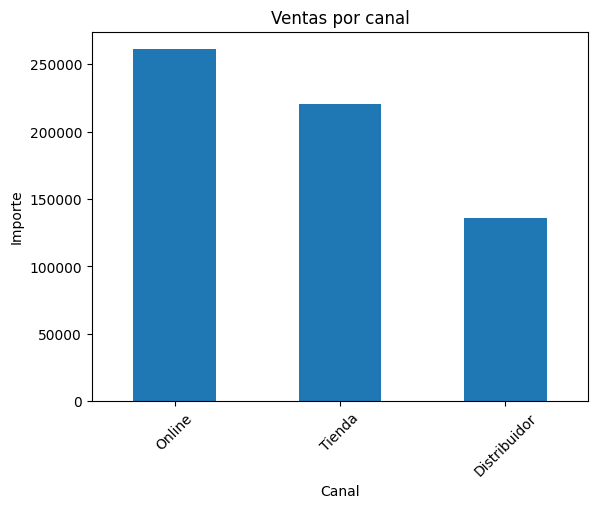

In [7]:
plt.figure()
ventas_por_canal.plot(kind="bar")
plt.title("Ventas por canal")
plt.xlabel("Canal")
plt.ylabel("Importe")
plt.xticks(rotation=45)
plt.show()

## Conclusiones

In [8]:
canal_top = ventas_por_canal.index[0]
region_top = ticket_medio_region.index[0]

print(f"El canal con más ventas es: {canal_top}")
print(f"La región con mayor ticket medio es: {region_top}")
print(f"La categoría con más unidades vendidas es: {categoria_top_unidades}")

El canal con más ventas es: Online
La región con mayor ticket medio es: Sin informar
La categoría con más unidades vendidas es: Alimentación


## Paso 2 — Análisis por canal y conclusiones

In [9]:
# Análisis por canal
resumen_canal = df_limpio.groupby("canal").agg(
    ventas_totales=("importe","sum"),
    descuento_medio=("descuento","mean")
).sort_values("descuento_medio", ascending=False)

resumen_canal

,ventas_totales,descuento_medio
canal,,
Online,"261,172.610",0.071
Tienda,"220,217.410",0.067
Distribuidor,"136,131.490",0.066


In [10]:
# Identificación de métricas clave
mejor_canal_conversion = resumen_canal.index[0]
mayor_ventas = resumen_canal["ventas_totales"].idxmax()

mejor_canal_conversion, mayor_ventas

('Online', 'Online')

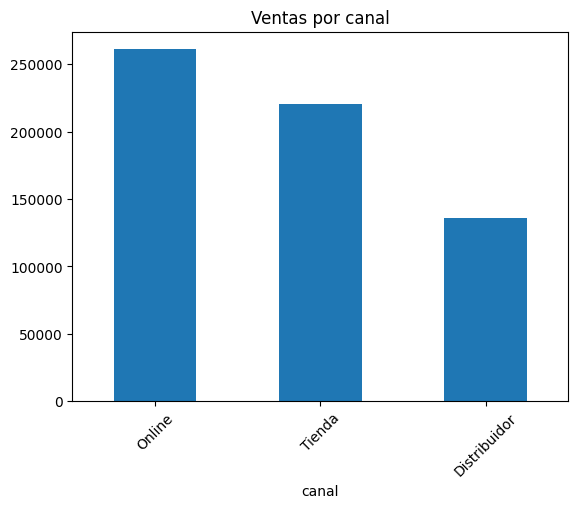

In [11]:
# Visualización
plt.figure()
resumen_canal["ventas_totales"].plot(kind="bar")
plt.title("Ventas por canal")
plt.xticks(rotation=45)
plt.show()

## Conclusiones ampliadas

In [12]:
print(f"El canal con mayor nivel de descuento medio es {mejor_canal_conversion}.")
print(f"El canal con mayor volumen de ventas es {mayor_ventas}.")

if mejor_canal_conversion == mayor_ventas:
    print("Ambos coinciden, lo que sugiere que el canal más agresivo en descuentos también lidera en volumen.")
else:
    print("No coinciden, lo que sugiere diferencias entre volumen de ventas y estrategia comercial por canal.")

El canal con mayor nivel de descuento medio es Online.
El canal con mayor volumen de ventas es Online.
Ambos coinciden, lo que sugiere que el canal más agresivo en descuentos también lidera en volumen.
